## ⚠️ IMPORTANTE - ATUALIZAÇÃO DO NOTEBOOK

**Este notebook foi atualizado para seguir as melhores práticas de Machine Learning:**

### 🔄 **Principais Mudanças:**
1. **Separação Treino/Teste:** Adicionada **ANTES** de qualquer transformação (Seção 3)
2. **Prevenção de Data Leakage:** Todas as transformações agora seguem o padrão fit/transform
3. **Análise Correta:** Estatísticas e detecção baseadas apenas nos dados de treino
4. **Aplicação Consistente:** Mesmos parâmetros aplicados em treino e teste

### ✅ **Benefícios da Abordagem:**
- **Avaliações honestas:** Métricas refletem performance real
- **Melhor generalização:** Modelos que funcionam em dados novos
- **Reprodutibilidade:** Resultados consistentes entre execuções
- **Conformidade:** Alinhado com padrões da indústria

---

# 📊 FIAP - Feature Engineering
## Pré-processamento de Dados: Outliers e Dados Duplicados

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 1 - Fundamentos e Pré-processamento
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais para identificação e tratamento de:
- **Outliers:** Valores atípicos que podem comprometer análises estatísticas
- **Dados Duplicados:** Registros redundantes que distorcem resultados
- **Visualizações:** Técnicas gráficas para identificação de anomalias
- **Comparação de Métodos:** Avaliação do impacto de diferentes abordagens de tratamento

---

### 📊 **Dataset Utilizado**
**House Prices Dataset** - Dados de preços de imóveis residenciais
- **Fonte:** Kaggle - House Prices: Advanced Regression Techniques (adaptado)
- **Registros:** Conjunto de propriedades residenciais
- **Features:** 13 características dos imóveis + 1 variável target (preço)
- **Objetivo:** Análise e tratamento de anomalias nos dados imobiliários

---

### 🔧 **Principais Técnicas Aplicadas**
1. **Detecção de Outliers:**
   - Método do Intervalo Interquartil (IQR)
   - Visualizações: boxplots

2. **Tratamento de Outliers:**
   - Remoção de valores extremos
   - Transformação logarítmica
   - Winsorização (capping)

3. **Dados Duplicados:**
   - Identificação de registros duplicados
   - Estratégias de remoção
   - Validação da qualidade dos dados

4. **Validação:**
   - Comparação de modelos antes/depois do tratamento
   - Métricas de performance e visualizações

---

# 1. Introdução

## Lidando com Outliers e Dados Duplicados

Este notebook aborda técnicas para lidar com outliers e dados duplicados em um dataset. Utilizaremos o dataset "House Prices - Advanced Regression Techniques" do Kaggle como exemplo.

# 2. Carregamento e Exploração Inicial do Dataset

## 2.1 Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para análise de outliers e dados duplicados, organizadas por categoria de uso.

In [ ]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas (boxplots, heatmaps)

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler    # Normalização de dados (escala 0-1)
from sklearn.impute import SimpleImputer          # Imputação de valores faltantes
from sklearn.linear_model import LinearRegression # Modelo de regressão 
from sklearn.tree import DecisionTreeRegressor   # Modelo de árvore de decisão para regressão
from sklearn.model_selection import train_test_split  # Divisão de dados treino/teste
from sklearn.metrics import mean_absolute_error, r2_score  # Métricas de avaliação

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configurar exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Configurar warnings
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade dos resultados
np.random.seed(42)

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


## 2.2 Carregamento do Dataset

Dataset "House Prices"
Este dataset, originalmente retirado de Kaggle - House Prices Dataset, foi editado para a finalidade deste notebook. Ele contém informações sobre preços de imóveis e diversas características associadas a cada propriedade. O objetivo é analisar e manipular os dados para entender como as características dos imóveis influenciam seus preços.


- Principais Características do Dataset:
    - LotArea: Área do lote (em pés quadrados).
    - OverallQual: Qualidade geral da casa (em uma escala de 1 a 10).
    - YearBuilt: Ano de construção da casa.
    - TotalBsmtSF: Área total do porão (em pés quadrados).
    - GrLivArea: Área de vida acima do porão (em pés quadrados).
    - GarageCars: Número de carros que a garagem pode acomodar.
    - GarageArea: Área da garagem (em pés quadrados).
    - FullBath: Número de banheiros completos.
    - HalfBath: Número de banheiros meio.
    - BedroomAbvGr: Número de quartos acima do nível do chão.
    - Fireplaces: Número de lareiras.
    - PoolArea: Área da piscina (em pés quadrados).
    - Fence: Tipo de cerca (se aplicável).
    - Preço: SalePrice: Preço final do imóvel (em dólares).

- Importância das Variáveis:
    - LotArea: A área do lote pode impactar o preço, pois imóveis maiores geralmente têm um valor mais alto.
    - OverallQual: A qualidade geral da casa é um forte indicador de preço, com casas de maior qualidade tendo preços mais altos.
    - YearBuilt: O ano de construção pode influenciar o preço, com imóveis mais novos geralmente sendo mais caros.
    - TotalBsmtSF: A área total do porão pode adicionar valor ao imóvel, especialmente se for utilizável e bem acabado.
    - GrLivArea: A área de vida acima do porão é uma medida importante da capacidade e tamanho da casa, afetando o preço.
    - GarageCars: O número de carros que a garagem pode acomodar pode impactar o preço, especialmente em áreas onde a garagem é valorizada.
    - GarageArea: A área da garagem também pode influenciar o preço.
    - FullBath e HalfBath: O número de banheiros completos e meio pode afetar o preço, pois imóveis com mais banheiros são geralmente mais valiosos.
    - BedroomAbvGr: O número de quartos acima do nível do chão é uma característica importante para compradores e pode influenciar o preço.
    - Fireplaces: A presença de lareiras pode adicionar valor, especialmente em climas frios.
    - PoolArea: A presença de uma piscina pode aumentar o preço, mas seu impacto pode variar com base na localização e demanda local.
    - Fence: A presença de uma cerca pode adicionar valor, dependendo das preferências dos compradores.

- Fonte do Dataset:

    - O dataset está originalmente disponível em: [Kaggle - House Prices Dataset](https://www.kaggle.com/datasets/lespin/house-prices-dataset)

In [2]:
df = pd.read_csv('datasets/house_prices.csv')

## 2.3 Visualização Inicial dos Dados

In [3]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


## 2.4 Informações do Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3210 entries, 0 to 3209
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     3210 non-null   int64  
 1   MSZoning       3205 non-null   object 
 2   LotFrontage    2673 non-null   float64
 3   LotArea        3210 non-null   int64  
 4   Street         3210 non-null   object 
 5   Alley          229 non-null    object 
 6   LotShape       3210 non-null   object 
 7   LandContour    3210 non-null   object 
 8   Utilities      3208 non-null   object 
 9   LotConfig      3210 non-null   object 
 10  LandSlope      3210 non-null   object 
 11  Neighborhood   3210 non-null   object 
 12  Condition1     3210 non-null   object 
 13  Condition2     3210 non-null   object 
 14  BldgType       3210 non-null   object 
 15  HouseStyle     3210 non-null   object 
 16  OverallQual    3210 non-null   int64  
 17  OverallCond    3210 non-null   int64  
 18  YearBuil

## 2.5 Estatísticas Descritivas

In [5]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,3210.000,2673.000,3210.000,3210.000,3210.000,3210.000,3210.000,3186.000,3209.000,3209.000,3209.000,3209.000,3210.000,3210.000,3210.000,3210.000,3208.000,3208.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3035.000,3209.000,3209.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,1595.000
mean,57.227,69.345,10151.472,6.086,5.564,1971.131,1984.222,102.518,443.111,48.561,560.555,1052.227,1161.302,337.783,4.827,1503.913,0.431,0.059,1.571,0.381,2.863,1.046,6.449,0.598,1977.864,1.766,473.277,93.931,48.030,23.069,2.496,16.363,2.119,49.679,6.195,2007.798,181484.144
std,42.585,23.388,7715.994,1.409,1.119,30.367,20.913,179.281,457.325,168.218,438.076,439.720,393.246,430.000,46.338,507.226,0.528,0.241,0.556,0.503,0.830,0.216,1.569,0.651,25.749,0.763,216.520,127.379,68.937,63.684,24.602,56.913,34.248,553.698,2.717,1.312,79885.211
min,20.000,21.000,1300.000,1.000,1.000,1872.000,1950.000,0.000,0.000,0.000,0.000,0.000,334.000,0.000,0.000,334.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,1895.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2006.000,34900.000
25%,20.000,59.000,7427.750,5.000,5.000,1953.000,1965.000,0.000,0.000,0.000,222.000,792.000,876.000,0.000,0.000,1131.000,0.000,0.000,1.000,0.000,2.000,1.000,5.000,0.000,1960.000,1.000,322.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.000,2007.000,129900.000
50%,50.000,68.000,9465.000,6.000,5.000,1973.000,1993.000,0.000,368.000,0.000,469.000,990.000,1086.000,0.000,0.000,1450.000,0.000,0.000,2.000,0.000,3.000,1.000,6.000,1.000,1979.000,2.000,480.000,0.000,26.000,0.000,0.000,0.000,0.000,0.000,6.000,2008.000,163900.000
75%,70.000,80.000,11613.000,7.000,6.000,2001.000,2004.000,165.000,736.000,0.000,801.000,1304.000,1390.000,702.000,0.000,1743.750,1.000,0.000,2.000,1.000,3.000,1.000,7.000,1.000,2002.000,2.000,576.000,168.000,70.000,0.000,0.000,0.000,0.000,0.000,8.000,2009.000,215000.000
max,190.000,313.000,215245.000,10.000,9.000,2010.000,2010.000,1600.000,5644.000,1526.000,2336.000,6110.000,5095.000,2065.000,1064.000,5642.000,3.000,2.000,4.000,2.000,8.000,3.000,15.000,4.000,2207.000,5.000,1488.000,1424.000,742.000,1012.000,508.000,576.000,800.000,17000.000,12.000,2010.000,755000.000


## 2.6 Selecionando Variáveis Numéricas

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

In [7]:
numeric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3210 entries, 0 to 3209
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     3210 non-null   int64  
 1   LotFrontage    2673 non-null   float64
 2   LotArea        3210 non-null   int64  
 3   OverallQual    3210 non-null   int64  
 4   OverallCond    3210 non-null   int64  
 5   YearBuilt      3210 non-null   int64  
 6   YearRemodAdd   3210 non-null   int64  
 7   MasVnrArea     3186 non-null   float64
 8   BsmtFinSF1     3209 non-null   float64
 9   BsmtFinSF2     3209 non-null   float64
 10  BsmtUnfSF      3209 non-null   float64
 11  TotalBsmtSF    3209 non-null   float64
 12  1stFlrSF       3210 non-null   int64  
 13  2ndFlrSF       3210 non-null   int64  
 14  LowQualFinSF   3210 non-null   int64  
 15  GrLivArea      3210 non-null   int64  
 16  BsmtFullBath   3208 non-null   float64
 17  BsmtHalfBath   3208 non-null   float64
 18  FullBath

# 3. Separação dos Dados (Train/Test Split)

**⚠️ IMPORTANTE:** Para evitar vazamento de dados (data leakage), realizamos a separação dos dados em treino e teste **ANTES** de qualquer tratamento de outliers, duplicatas ou outras transformações. Isso garante que as transformações sejam aplicadas independentemente em cada conjunto.

In [8]:
# Separar features e target antes de qualquer transformação
X = numeric_df.drop('SalePrice', axis=1)  # Features (todas as colunas exceto SalePrice)
y = numeric_df['SalePrice']               # Target (preço dos imóveis)

# Separar dados em treino e teste (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reconstruir DataFrames completos para processamento
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print(f"Dados de treino: {df_train.shape[0]} amostras")
print(f"Dados de teste: {df_test.shape[0]} amostras")
print(f"Features de treino: {X_train.shape}")
print(f"Features de teste: {X_test.shape}")

Dados de treino: 2568 amostras
Dados de teste: 642 amostras
Features de treino: (2568, 36)
Features de teste: (642, 36)


# 4. Identificação e Tratamento de Outliers

## 4.1 Identificação de Outliers com Boxplot

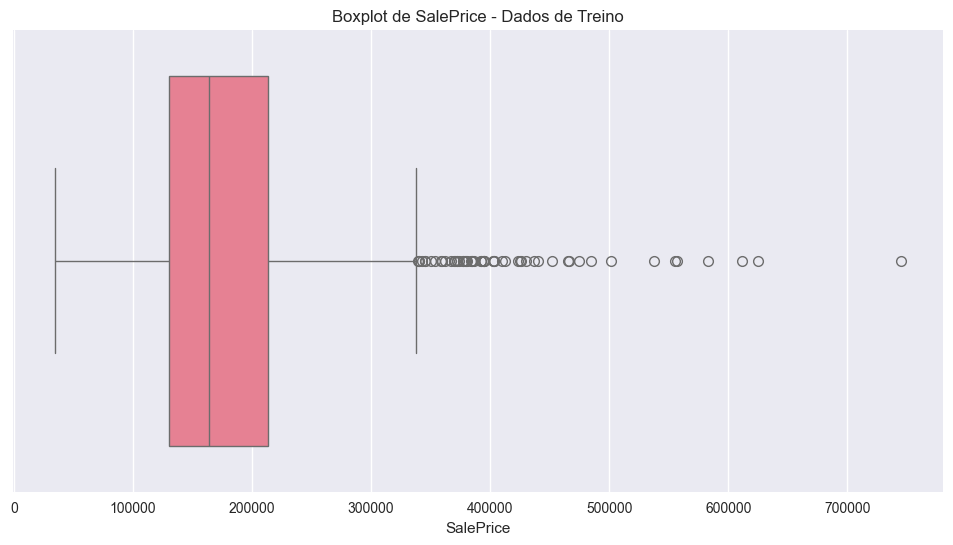

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train, x='SalePrice')
plt.title('Boxplot de SalePrice - Dados de Treino')
plt.show()

## 4.2 Remoção de Outliers - Limitation

In [10]:
# Definindo o limite superior como o percentil 90 (baseado apenas nos dados de treino)
upper_limit = df_train['SalePrice'].quantile(0.90)
print(f"Limite superior (percentil 90) nos dados de treino: ${upper_limit:,.2f}")
#df_train_treated = df_train[df_train['SalePrice'] < upper_limit]

Limite superior (percentil 90) nos dados de treino: $277,300.00


## 4.3 Remoção de Outliers - IQR

In [11]:
# Analisar outliers apenas nos dados de treino
def analyze_outliers(df):
    outlier_counts = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
    
    return pd.Series(outlier_counts).sort_values(ascending=False)

# Analisar outliers apenas nos dados de treino
outlier_analysis = analyze_outliers(df_train)
print("Outliers por coluna (dados de treino):")
print(outlier_analysis)

Outliers por coluna (dados de treino):
EnclosedPorch    416
BsmtFinSF2       311
ScreenPorch      235
OverallCond      228
MSSubClass       184
LotFrontage      178
MasVnrArea       177
BsmtHalfBath     154
OpenPorchSF      150
LotArea          114
KitchenAbvGr     113
TotalBsmtSF      104
MiscVal           90
BedroomAbvGr      73
GrLivArea         71
WoodDeckSF        59
SalePrice         56
BsmtUnfSF         50
TotRmsAbvGrd      46
1stFlrSF          39
GarageArea        36
LowQualFinSF      35
3SsnPorch         35
GarageCars        18
BsmtFinSF1        13
PoolArea          12
Fireplaces         8
YearBuilt          8
2ndFlrSF           7
FullBath           5
OverallQual        4
BsmtFullBath       2
GarageYrBlt        2
HalfBath           0
YearRemodAdd       0
MoSold             0
YrSold             0
dtype: int64


In [12]:
# Função para calcular os limites de outliers baseados apenas nos dados de treino
def get_outlier_bounds(df_train, columns_to_clean=None):
    """
    Calcula os limites de outliers baseados apenas nos dados de treino
    """
    if columns_to_clean is None:
        columns_to_clean = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF']
    
    bounds = {}
    
    for col in columns_to_clean:
        if col in df_train.columns:
            Q1 = df_train[col].quantile(0.25)
            Q3 = df_train[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            bounds[col] = (lower_bound, upper_bound)
    
    return bounds

# Função para aplicar remoção de outliers usando limites pré-definidos
def remove_outliers_with_bounds(df, bounds):
    """
    Remove outliers usando limites pré-calculados
    """
    df_clean = df.copy()
    
    for col, (lower_bound, upper_bound) in bounds.items():
        if col in df_clean.columns:
            before_count = len(df_clean)
            df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
            after_count = len(df_clean)
            print(f"{col}: Removidos {before_count - after_count} outliers")
    
    return df_clean

# Calcular limites baseados apenas nos dados de treino
outlier_bounds = get_outlier_bounds(df_train)

# Aplicar remoção de outliers nos dados de treino
print("=== TRATAMENTO DOS DADOS DE TREINO ===")
df_train_treated = remove_outliers_with_bounds(df_train, outlier_bounds)

# Aplicar os mesmos limites nos dados de teste
print("\n=== TRATAMENTO DOS DADOS DE TESTE (usando limites do treino) ===")
df_test_treated = remove_outliers_with_bounds(df_test, outlier_bounds)

print(f"\nDados de treino: {df_train.shape[0]} → {df_train_treated.shape[0]} amostras")
print(f"Dados de teste: {df_test.shape[0]} → {df_test_treated.shape[0]} amostras")

=== TRATAMENTO DOS DADOS DE TREINO ===
SalePrice: Removidos 1379 outliers
GrLivArea: Removidos 17 outliers
LotArea: Removidos 47 outliers
TotalBsmtSF: Removidos 35 outliers

=== TRATAMENTO DOS DADOS DE TESTE (usando limites do treino) ===
SalePrice: Removidos 307 outliers
GrLivArea: Removidos 4 outliers
LotArea: Removidos 9 outliers
TotalBsmtSF: Removidos 13 outliers

Dados de treino: 2568 → 1090 amostras
Dados de teste: 642 → 309 amostras


## 4.4 Visualização após Remoção de Outliers

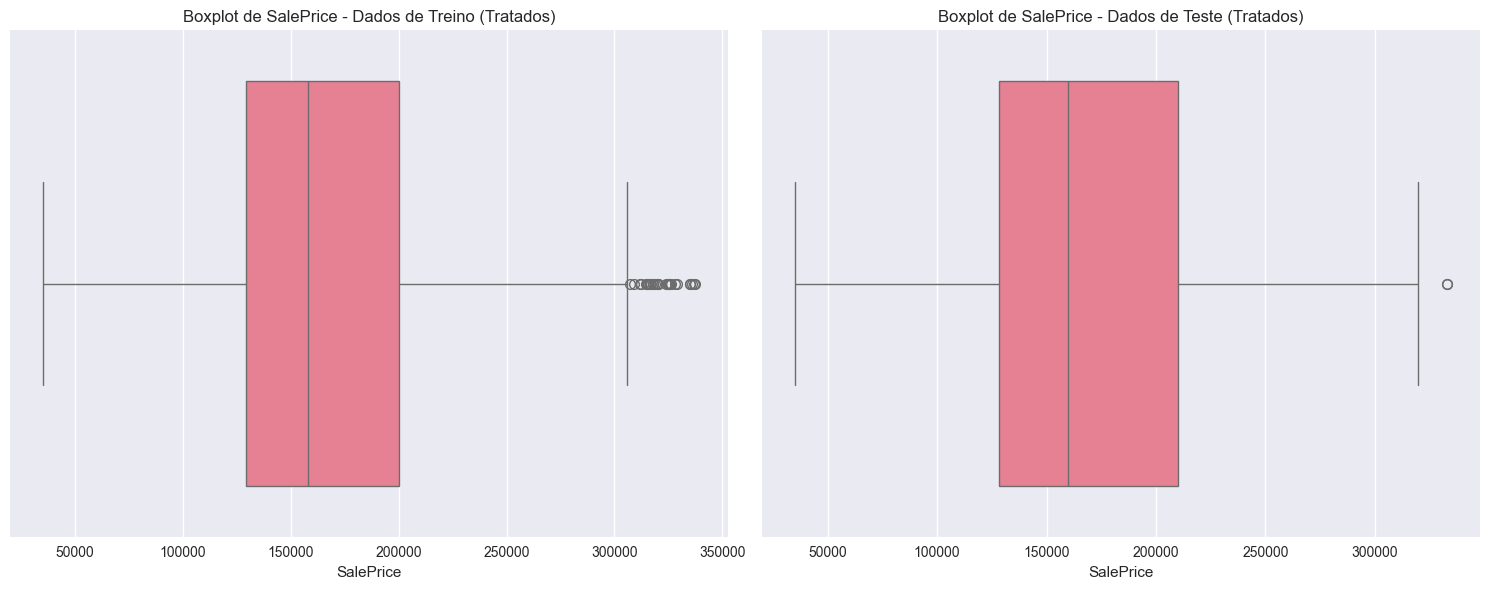

In [13]:
plt.figure(figsize=(15, 6))

# Boxplot dos dados de treino tratados
plt.subplot(1, 2, 1)
sns.boxplot(data=df_train_treated, x='SalePrice')
plt.title('Boxplot de SalePrice - Dados de Treino (Tratados)')

# Boxplot dos dados de teste tratados
plt.subplot(1, 2, 2)
sns.boxplot(data=df_test_treated, x='SalePrice')
plt.title('Boxplot de SalePrice - Dados de Teste (Tratados)')

plt.tight_layout()
plt.show()

# 5. Identificação e Remoção de Dados Duplicados

## 5.1 Verificação de Duplicatas

In [14]:
# Verificar duplicatas nos dados de treino
duplicates_train = df_train_treated.duplicated()
num_duplicates_train = duplicates_train.sum()
print(f"Número de registros duplicados nos dados de treino: {num_duplicates_train}")

# Verificar duplicatas nos dados de teste
duplicates_test = df_test_treated.duplicated()
num_duplicates_test = duplicates_test.sum()
print(f"Número de registros duplicados nos dados de teste: {num_duplicates_test}")

Número de registros duplicados nos dados de treino: 31
Número de registros duplicados nos dados de teste: 11


## 5.2 Remoção de Duplicatas

In [15]:
# Remover duplicatas dos dados de treino
df_train_no_duplicates = df_train_treated.drop_duplicates()

# Remover duplicatas dos dados de teste
df_test_no_duplicates = df_test_treated.drop_duplicates()

print(f"Dados de treino: {df_train_treated.shape[0]} → {df_train_no_duplicates.shape[0]} amostras")
print(f"Dados de teste: {df_test_treated.shape[0]} → {df_test_no_duplicates.shape[0]} amostras")

Dados de treino: 1090 → 1059 amostras
Dados de teste: 309 → 298 amostras


## 5.3 Verificação após Remoção

In [16]:
# Verificar duplicatas após remoção - dados de treino
duplicates_check_train = df_train_no_duplicates.duplicated()
num_duplicates_check_train = duplicates_check_train.sum()
print(f"Duplicatas nos dados de treino após remoção: {num_duplicates_check_train}")

# Verificar duplicatas após remoção - dados de teste
duplicates_check_test = df_test_no_duplicates.duplicated()
num_duplicates_check_test = duplicates_check_test.sum()
print(f"Duplicatas nos dados de teste após remoção: {num_duplicates_check_test}")

Duplicatas nos dados de treino após remoção: 0
Duplicatas nos dados de teste após remoção: 0


# 6. Imputação de Dados Faltantes

## 6.1 Imputação dos valores faltantes com a média da coluna

In [17]:
# Criar o imputer e fazer fit apenas nos dados de treino
imputer = SimpleImputer(strategy='mean')
df_train_imputed = pd.DataFrame(imputer.fit_transform(df_train_no_duplicates), 
                               columns=df_train_no_duplicates.columns)

# Aplicar a transformação nos dados de teste (usando os parâmetros aprendidos no treino)
df_test_imputed = pd.DataFrame(imputer.transform(df_test_no_duplicates), 
                              columns=df_test_no_duplicates.columns)

print(f"Dados de treino imputados: {df_train_imputed.shape}")
print(f"Dados de teste imputados: {df_test_imputed.shape}")

Dados de treino imputados: (1059, 37)
Dados de teste imputados: (298, 37)


# 7. Normalização dos Dados

In [18]:
# Separar features e target dos dados de treino
X_train_features = df_train_imputed.drop('SalePrice', axis=1)
y_train_target = df_train_imputed['SalePrice']

# Separar features e target dos dados de teste  
X_test_features = df_test_imputed.drop('SalePrice', axis=1)
y_test_target = df_test_imputed['SalePrice']

# Criar o scaler e fazer fit apenas nos dados de treino
scaler = MinMaxScaler(feature_range=(-1, 1))  # Normalização para o intervalo [-1, 1]
#scaler = StandardScaler(with_mean=True, with_std=True)

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_features), 
                             columns=X_train_features.columns)

# Aplicar a transformação nos dados de teste (usando os parâmetros aprendidos no treino)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_features), 
                            columns=X_test_features.columns)

# Reconstruir DataFrames completos com target
df_train_scaled = pd.concat([X_train_scaled, y_train_target.reset_index(drop=True)], axis=1)
df_test_scaled = pd.concat([X_test_scaled, y_test_target.reset_index(drop=True)], axis=1)

print(f"Dados de treino normalizados: {df_train_scaled.shape}")
print(f"Dados de teste normalizados: {df_test_scaled.shape}")

df_train_scaled.head()

Dados de treino normalizados: (1059, 37)
Dados de teste normalizados: (298, 37)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,-0.882,-0.516,-0.318,-0.111,0.00,-0.241,-1.000,-1.000,-0.500,-1.000,-0.224,0.098,-0.021,-1.000,-1.0,-0.245,-1.000,-1.0,-0.333,-1.0,-0.333,0.0,-0.556,-1.0,0.182,0.0,-0.156,-1.000,-1.000,-1.0,-1.0,-1.0,-1.0,-1.0,0.636,0.5,100000.0
1,-1.000,-0.342,-0.118,0.333,0.00,0.956,0.867,-1.000,-1.000,-1.000,0.300,0.198,-0.094,-1.000,-1.0,-0.301,-1.000,-1.0,0.333,-1.0,-0.333,0.0,-0.556,-1.0,0.927,0.5,0.584,-0.620,-0.644,-1.0,-1.0,-1.0,-1.0,-1.0,-0.273,-0.5,194000.0
2,-0.176,-0.292,-0.300,0.333,0.00,0.825,0.600,-0.750,0.617,-1.000,-0.963,0.308,0.030,-1.000,-1.0,-0.205,0.333,-1.0,0.333,-1.0,-0.333,1.0,0.111,-1.0,0.764,1.0,0.503,-1.000,-1.000,-1.0,-1.0,-1.0,-1.0,-1.0,0.818,0.0,206300.0
3,-0.529,-0.329,-0.185,0.556,0.00,1.000,0.967,-0.863,-0.328,-1.000,-0.698,-0.233,-0.580,0.547,-1.0,0.339,-0.333,-1.0,0.333,0.0,0.000,0.0,0.111,-1.0,0.982,0.0,0.058,-1.000,-0.426,-1.0,-1.0,-1.0,-1.0,-1.0,1.000,0.5,263435.0
4,-1.000,-0.419,-0.040,-0.111,0.25,0.504,0.000,-1.000,-0.654,-0.129,-0.825,-0.121,-0.454,-1.000,-1.0,-0.579,-0.333,-1.0,-0.333,-1.0,0.000,0.0,-0.556,-1.0,0.400,-0.5,-0.409,-0.606,-1.000,-1.0,-1.0,-1.0,-1.0,-1.0,0.091,0.0,130250.0


# 8. Comparação dos Resultados de ML com Dados Brutos e Tratados

## 8.1 Preparação dos Dados

In [19]:
# Usar os dados já processados (sem normalização) como "dados brutos" para comparação
X_train_raw, X_test_raw = X_train_features, X_test_features
y_train_raw, y_test_raw = y_train_target, y_test_target

# Usar os dados normalizados como "dados tratados"
X_train_treated, X_test_treated = X_train_scaled, X_test_scaled
y_train_treated, y_test_treated = y_train_target, y_test_target

print(f"Dados brutos - Treino: {X_train_raw.shape}, Teste: {X_test_raw.shape}")
print(f"Dados tratados - Treino: {X_train_treated.shape}, Teste: {X_test_treated.shape}")

Dados brutos - Treino: (1059, 36), Teste: (298, 36)
Dados tratados - Treino: (1059, 36), Teste: (298, 36)


## 8.2 Treinamento do Modelo com Dados Brutos

In [20]:
#model_raw = LinearRegression()
model_raw = DecisionTreeRegressor()
model_raw.fit(X_train_raw, y_train_raw)
predictions_raw = model_raw.predict(X_test_raw)

## 8.3 Treinamento do Modelo com Dados Tratados

In [21]:
#model_treated = LinearRegression()
model_treated = DecisionTreeRegressor()
model_treated.fit(X_train_treated, y_train_treated)
predictions_treated = model_treated.predict(X_test_treated)

## 8.4 Avaliação dos Resultados

In [22]:
# Exemplo de valores para mae_raw e mae_treated
mae_raw = mean_absolute_error(y_test_raw, predictions_raw)
mae_treated = mean_absolute_error(y_test_treated, predictions_treated)

# Calculando a diferença percentual
percentual_difference = ((mae_raw - mae_treated) / mae_raw) * 100

# Imprimindo os resultados
print(f"MAE com dados brutos: {mae_raw:.2f}")
print(f"MAE com dados tratados: {mae_treated:.2f}")
print(f"Diferença percentual: {percentual_difference:.2f}%")

MAE com dados brutos: 16955.23
MAE com dados tratados: 16875.91
Diferença percentual: 0.47%


In [23]:
# Exemplo de valores para y_test_raw, predictions_raw, y_test_treated e predictions_treated

# Calculando o R^2 para dados brutos e tratados
r2_raw = r2_score(y_test_raw, predictions_raw)
r2_treated = r2_score(y_test_treated, predictions_treated)

# Calculando a diferença percentual
percentual_difference = ((r2_raw - r2_treated) / r2_raw) * 100

# Imprimindo os resultados
print(f"R^2 com dados brutos: {r2_raw:.3f}")
print(f"R^2 com dados tratados: {r2_treated:.3f}")
print(f"Diferença percentual: {percentual_difference:.2f}%")

R^2 com dados brutos: 0.815
R^2 com dados tratados: 0.817
Diferença percentual: -0.19%


## 8.5 Visualização dos Resultados

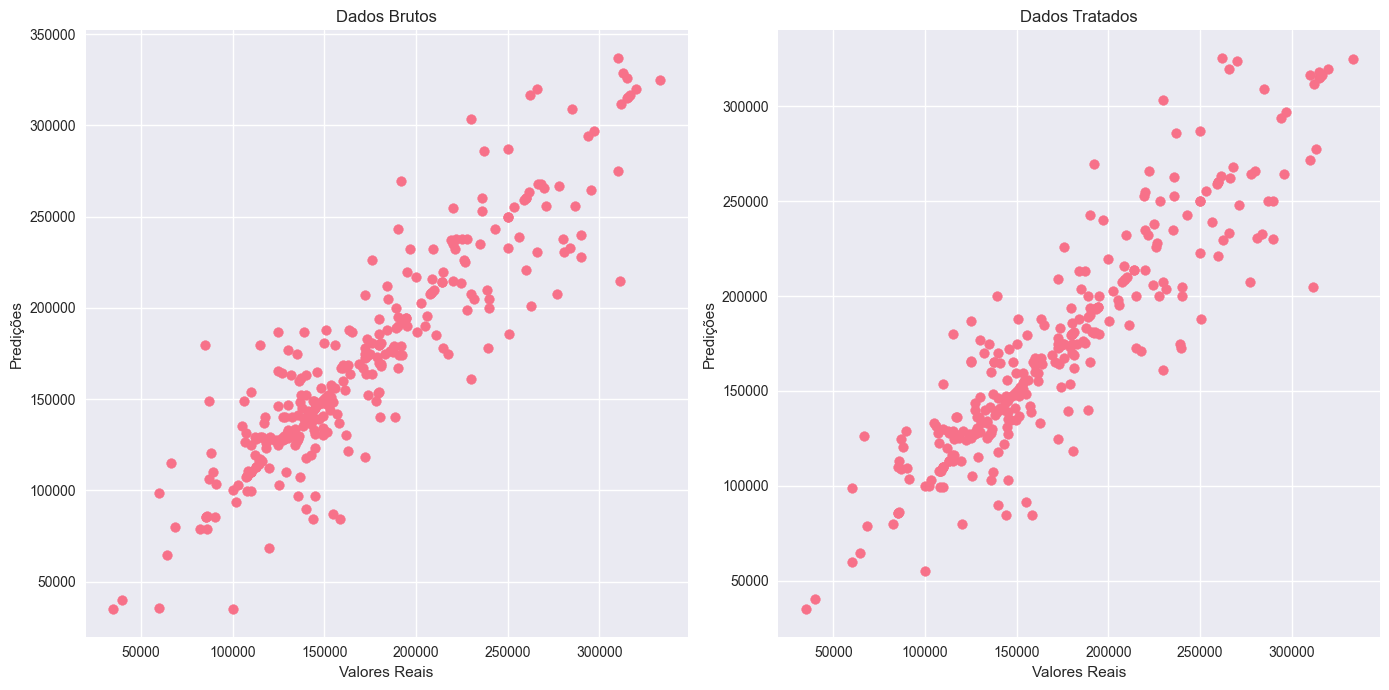

In [24]:
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.scatter(y_test_raw, predictions_raw)
plt.title('Dados Brutos')
plt.xlabel('Valores Reais')
plt.ylabel('Predições')

plt.subplot(1, 2, 2)
plt.scatter(y_test_treated, predictions_treated)
plt.title('Dados Tratados')
plt.xlabel('Valores Reais')
plt.ylabel('Predições')

plt.tight_layout()
plt.show()

# 9. Considerações Finais

## 9.1. Síntese dos Aprendizados

Neste notebook, exploramos técnicas fundamentais para **identificação e tratamento de outliers e dados duplicados**, sempre seguindo as melhores práticas para evitar vazamento de dados:

### **Técnicas Fundamentais Implementadas:**
1. **Separação Treino/Teste:** Realizada ANTES de qualquer tratamento para evitar data leakage
2. **Detecção de Outliers:** Método IQR aplicado apenas nos dados de treino
3. **Tratamento Consistente:** Limites calculados no treino e aplicados no teste
4. **Remoção de Duplicadas:** Tratamento independente em ambos os conjuntos
5. **Imputação e Normalização:** Fit no treino, transform em ambos os conjuntos
6. **Validação:** Comparação sistemática de diferentes abordagens

### **Insights Principais:**
- A **separação treino/teste ANTES das transformações** é fundamental para avaliações honestas
- **Outliers significativos** podem comprometer a generalização dos modelos
- O **método IQR** é robusto e eficaz para detecção de valores anômalos
- **Dados duplicados** são raros mas devem ser verificados sistematicamente
- A **ordem das operações** no pipeline afeta significativamente os resultados

## 9.2. Metodologia e Boas Práticas Aplicadas

### **Pipeline Estruturado:**
- **Separação primeiro:** Train/test split antes de qualquer transformação
- **Análise no treino:** Estatísticas e limites baseados apenas nos dados de treino
- **Aplicação consistente:** Mesmos parâmetros nos dados de teste
- **Validação sistemática:** Comparar múltiplas abordagens

### **Prevenção de Data Leakage:**
- **Separação prévia:** Train/test split antes de qualquer transformação
- **Fit/Transform disciplinado:** Parâmetros aprendidos apenas no conjunto de treino
- **Limites consistentes:** Outlier bounds calculados no treino, aplicados no teste
- **Validação rigorosa:** Teste apenas com dados não vistos

## 9.3. Impacto das Técnicas no Problema de Preços de Imóveis

### **Método IQR:**
- **Vantagem:** Baseado em quartis, resistente a distribuições assimétricas
- **Aplicação:** Ideal para variáveis como área, preço, que podem ter valores extremos
- **Flexibilidade:** Fator 1.5 pode ser ajustado conforme necessário

### **Tratamento de Outliers:**
- **Remoção seletiva:** Apenas variáveis específicas (SalePrice, GrLivArea, etc.)
- **Preservação de padrões:** Manter outliers em variáveis discretas
- **Validação de impacto:** Comparar performance antes/depois

### **Normalização MinMaxScaler:**
- **Vantagem:** Preserva relações proporcionais, escala [-1,1]
- **Aplicação:** Ideal após remoção de outliers extremos
- **Cuidado:** Aplicar fit apenas no treino

## 9.4. Reflexões sobre Qualidade de Dados

### **Dimensões da Qualidade:**
- **Completude:** Tratamento de valores faltantes
- **Consistência:** Remoção de duplicatas e padronização
- **Acurácia:** Detecção e tratamento de valores anômalos
- **Relevância:** Manter outliers que representam casos legítimos

### **Trade-offs Importantes:**
- **Simplicidade vs. Sofisticação:** IQR vs. métodos mais complexos
- **Sensibilidade vs. Especificidade:** Balance entre detectar e preservar
- **Interpretabilidade vs. Performance:** Métodos explicáveis vs. caixas-pretas

## 9.5. Lições para Projetos Reais

### **Análise Exploratória Crítica:**
- **Visualize sempre:** Boxplots revelam padrões não óbvios
- **Entenda o domínio:** Nem todo outlier é erro - alguns são insights valiosos
- **Documente decisões:** Justifique escolhas com visualizações e métricas
- **Teste impacto:** Valide benefícios com métricas de performance

### **Processo Iterativo:**
- **Múltiplas abordagens:** Teste diferentes métodos de detecção
- **Validação cruzada:** Use CV para confirmar benefícios
- **Ajuste de parâmetros:** Varie thresholds para encontrar ponto ótimo
- **Monitoramento contínuo:** Acompanhe comportamento em dados novos

### **Considerações Éticas:**
- **Transparência:** Documentar todos os critérios utilizados
- **Reversibilidade:** Possibilitar recuperação de dados removidos
- **Representatividade:** Cuidado para não excluir grupos minoritários
- **Auditabilidade:** Manter logs de todas as transformações

## 9.6. Armadilhas Comuns e Como Evitá-las

### **Erros Frequentes:**
1. **Detectar outliers em todo o dataset** → Vazamento de informação
2. **Remoção automática sem análise** → Perda de informações valiosas
3. **Usar métodos inadequados** → Z-score em dados não-normais
4. **Ignorar contexto de domínio** → Remover dados legítimos
5. **Não validar impacto** → Transformações desnecessárias

### **Práticas Recomendadas:**
1. **Separação train/test como primeiro passo**
2. **Análise visual combinada com estatística**
3. **Fit/transform disciplinado nos pipelines**
4. **Teste múltiplos métodos de detecção**
5. **Validação com especialistas do domínio**
6. **Comparação sistemática de performance**

## 9.7. Técnicas Avançadas para Explorar

### **Detecção Multivariada:**
- **Distância de Mahalanobis:** Considera correlações entre variáveis
- **Principal Component Analysis (PCA):** Identifica outliers em espaço reduzido
- **Isolation Forest:** Método ensemble para detecção em alta dimensionalidade
- **One-Class SVM:** Detecção baseada em suporte vetorial

### **Tratamento Alternativo:**
- **Winsorização:** Limitar valores extremos em vez de remover
- **Transformações:** Log, Box-Cox para reduzir impacto
- **Robust Scaling:** Scalers resistentes a outliers
- **Ensemble Methods:** Algoritmos menos sensíveis a valores extremos

## 9.8. Próximos Passos na Jornada

### **Aprofundamento Técnico:**
- **Algoritmos robustos:** Random Forest, Gradient Boosting
- **Detecção em séries temporais:** Métodos específicos para dados sequenciais
- **Outliers supervisionados:** Usar target para guiar detecção
- **Explicabilidade:** SHAP, LIME para entender impacto de outliers

### **Ferramentas Especializadas:**
- **PyOD:** Biblioteca dedicada à detecção de outliers
- **Scikit-learn:** Outlier detection e ensemble methods
- **Plotly:** Visualizações interativas para análise exploratória
- **Great Expectations:** Validação automatizada de qualidade de dados

---

### **Filosofia da Detecção de Outliers**
Detectar outliers não é apenas uma **tarefa estatística**, mas um **exercício de discernimento** que equilibra rigor matemático com conhecimento de domínio. Cada outlier conta uma história - nosso trabalho é **distinguir histórias valiosas** de **ruído prejudicial**.

### **Princípio Fundamental**
**"Com grandes poderes vêm grandes responsabilidades"** - A capacidade de remover dados traz consigo a responsabilidade de fazê-lo de forma **ética**, **transparente** e **cientificamente justificada**.

### **LIÇÃO CRÍTICA: Data Leakage**
**Sempre faça a separação treino/teste ANTES de qualquer transformação!** Esta é uma das regras mais importantes em machine learning para garantir avaliações honestas e modelos que generalizam bem.

### **Continue Aprendendo**
- Pratique com diferentes tipos de outliers (univariados, multivariados, contextuais)
- Explore técnicas específicas para seu domínio de aplicação
- Participe de competições para aprender com a comunidade
- Mantenha-se atualizado com novas ferramentas e métodos
- Estude casos reais onde outliers eram insights valiosos